In [83]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Lib


In [84]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [85]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Load


In [86]:
train_df = pd.read_csv("/content/drive/MyDrive/_colab/train.csv", parse_dates=["date"])
test_df = pd.read_csv("/content/drive/MyDrive/_colab/test.csv", parse_dates=["date"])

print(f"train_df: {train_df.shape}")
print(f"Train: {train_df['date'].min()} -> {train_df['date'].max()}")
print()
print(f"test_df : {test_df.shape}")
print(f"Test : {test_df['date'].min()} -> {test_df['date'].max()}")

train_df: (221940, 25)
Train: 2022-08-05 10:00:00 -> 2026-03-18 04:00:00

test_df : (24670, 25)
Test : 2026-03-18 05:00:00 -> 2026-06-28 23:00:00


In [87]:
ID_COLS = ["location_id", "location_name", "date"]
LABEL_COL = "aqi_category"
LEAKY_COLS = ["us_aqi"]

FEATURE_COLS = [
    c for c in train_df.columns if c not in ID_COLS + [LABEL_COL] + LEAKY_COLS
]

print(f"features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

features: 20
['temperature_2m', 'relative_humidity_2m', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'weather_code', 'sunshine_duration', 'boundary_layer_height', 'dew_point_2m', 'hour', 'month', 'day_of_week', 'is_weekend', 'season', 'hour_sin', 'hour_cos', 'us_aqi_lag1', 'us_aqi_lag3']


# Func


## utils


In [88]:
def prepare_encoder(
    df: pd.DataFrame,
    feature_cols: list,
    label_col: str,
    label_encoder: LabelEncoder = None,
):
    X = df[feature_cols].copy()

    if label_encoder is None:
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(df[label_col])
    else:
        y = label_encoder.transform(df[label_col])

    return X, y, label_encoder

## train


In [89]:
def train_model(model, X_train: pd.DataFrame, y_train: np.ndarray):
    model.fit(X_train, y_train)
    return model

## eval


In [90]:
def eval_model(
    model,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    label_encoder: LabelEncoder,
    model_name: str = "model",
) -> pd.DataFrame:
    y_pred = model.predict(X_test)

    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    return pd.DataFrame([metrics])


def plot_confusion_matrix(
    model,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    label_encoder: LabelEncoder,
    model_name: str = "model",
):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(12, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="coolwarm",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## predict


In [91]:
def predict_model(
    model,
    df: pd.DataFrame,
    feature_cols: list,
    label_encoder: LabelEncoder,
    column_transformer: ColumnTransformer,
    n_samples: int = 10,
    random_state: int = SEED,
) -> pd.DataFrame:
    n_samples = min(n_samples, len(df))
    sample_df = df.sample(n=n_samples, random_state=random_state).copy()

    X_sample_raw = sample_df[feature_cols]
    X_sample_scaled = column_transformer.transform(X_sample_raw)

    y_pred_encoded = model.predict(X_sample_scaled)
    y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

    sample_df["predicted"] = y_pred_labels

    return sample_df

# Main


## Preprocessing


### Encoder


In [92]:
# Label encoder
X_train, y_train, label_encoder = prepare_encoder(train_df, FEATURE_COLS, LABEL_COL)
X_test, y_test, _ = prepare_encoder(
    test_df, FEATURE_COLS, LABEL_COL, label_encoder=label_encoder
)
print("Classes:", list(enumerate(label_encoder.classes_)))
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

Classes: [(0, 'good'), (1, 'moderate'), (2, 'unhealthy'), (3, 'unhealthy for sensitive groups')]
X_train shape: (221940, 20) | X_test shape: (24670, 20)


### Scaler


In [93]:
# Cols to scale and not scale
NON_SCALE_COLS = [
    "weather_code",
    "month",
    "day_of_week",
    "season",
    "is_weekend",
    "hour_sin",
    "hour_cos",
]
NON_SCALE_COLS = [c for c in NON_SCALE_COLS if c in FEATURE_COLS]
SCALE_COLS = [c for c in FEATURE_COLS if c not in NON_SCALE_COLS]

print(f"Cols to scale: {len(SCALE_COLS)}")
print(SCALE_COLS)

Cols to scale: 13
['temperature_2m', 'relative_humidity_2m', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'sunshine_duration', 'boundary_layer_height', 'dew_point_2m', 'hour', 'us_aqi_lag1', 'us_aqi_lag3']


In [94]:
column_transformer = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), SCALE_COLS),
    ],
    remainder="passthrough",
)

X_train_scaled = column_transformer.fit_transform(X_train)
X_test_scaled = column_transformer.transform(X_test)

final_columns = SCALE_COLS + NON_SCALE_COLS

X_train = pd.DataFrame(
    X_train_scaled, columns=final_columns, index=train_df.index[: len(X_train_scaled)]
)
X_test = pd.DataFrame(
    X_test_scaled, columns=final_columns, index=test_df.index[: len(X_test_scaled)]
)

In [95]:
X_train.head()

,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,sunshine_duration,boundary_layer_height,dew_point_2m,hour,us_aqi_lag1,us_aqi_lag3,weather_code,month,day_of_week,season,is_weekend,hour_sin,hour_cos
0,0.820750,-0.524866,-0.248615,0.273237,0.660386,2.760048,1.213436,1.257629,0.095661,0.383802,-0.216874,-0.396615,-0.390756,3.0,8.0,4.0,0.0,1.0,0.5,-0.866025
1,0.955932,-0.378713,-0.157624,0.246279,0.660386,0.616282,0.970569,1.257629,0.084265,0.747273,-0.216874,-0.997816,-0.991976,51.0,8.0,4.0,0.0,1.0,0.5,-0.866025
2,0.634875,-0.360050,-0.157624,-1.118221,0.660386,0.512769,1.134623,1.257629,0.038678,0.403995,-0.216874,-0.710285,-0.691191,51.0,8.0,4.0,0.0,1.0,0.5,-0.866025
3,0.854545,-0.367554,-0.248615,0.356471,0.660386,0.820914,1.087750,1.257629,0.517340,0.646309,-0.216874,-0.014984,0.007618,3.0,8.0,4.0,0.0,1.0,0.5,-0.866025
4,0.854545,-0.396285,-0.248615,-0.082902,0.660386,0.981268,1.129375,1.257629,-0.177860,0.605923,-0.216874,-0.014984,0.007618,3.0,8.0,4.0,0.0,1.0,0.5,-0.866025


## Define model


In [96]:
models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ),
    "SVM": LinearSVC(
        class_weight="balanced",
        max_iter=2000,
        dual=False,
        random_state=SEED
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric="mlogloss",
        n_jobs=-1,
    ),
}

## Train


In [97]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

cv_results = []
trained_models_cv = {}

In [98]:
for name, model in models.items():
    fold_scores = []

    for fold, (train_index, val_index) in enumerate(tscv.split(X_train)):
        X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
        y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]
        model.fit(X_fold_train, y_fold_train)
        y_pred = model.predict(X_fold_val)
        score = f1_score(y_fold_val, y_pred, average="macro", zero_division=0)
        fold_scores.append(score)
        print(f"| {name:^15} | Fold {fold+1:02d} | Train size={len(X_fold_train):<8} | Val size={len(X_fold_val):<8} | F1-macro: {score:<5.4f}")

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)

    cv_results.append({
        "model_name": name,
        "mean_f1_macro": mean_score,
        "std_f1_macro": std_score,
        "all_folds": fold_scores
    })

    print(f"Average F1-macro: {mean_score:.4f} (±{std_score:.4f})\n")
    print("-" * 100)

    if name == "XGBoost":
        final_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight=final_weights)
    else:
        model.fit(X_train, y_train)
    trained_models_cv[name] = model

| LogisticRegression | Fold 01 | Train size=36990    | Val size=36990    | F1-macro: 0.7457
| LogisticRegression | Fold 02 | Train size=73980    | Val size=36990    | F1-macro: 0.8931
| LogisticRegression | Fold 03 | Train size=110970   | Val size=36990    | F1-macro: 0.8672
| LogisticRegression | Fold 04 | Train size=147960   | Val size=36990    | F1-macro: 0.8268
| LogisticRegression | Fold 05 | Train size=184950   | Val size=36990    | F1-macro: 0.8942
Average F1-macro: 0.8454 (±0.0555)

----------------------------------------------------------------------------------------------------
|       SVM       | Fold 01 | Train size=36990    | Val size=36990    | F1-macro: 0.7465
|       SVM       | Fold 02 | Train size=73980    | Val size=36990    | F1-macro: 0.8491
|       SVM       | Fold 03 | Train size=110970   | Val size=36990    | F1-macro: 0.8034
|       SVM       | Fold 04 | Train size=147960   | Val size=36990    | F1-macro: 0.8178
|       SVM       | Fold 05 | Train size=184950

## Eval


In [102]:
cv_df = pd.DataFrame(cv_results).drop(columns=['all_folds'])
cv_df = cv_df.sort_values("mean_f1_macro", ascending=False).reset_index(drop=True)
cv_df.round(4)

,model_name,mean_f1_macro,std_f1_macro
0,XGBoost,0.9028,0.0124
1,RandomForest,0.8823,0.0164
2,LogisticRegression,0.8454,0.0555
3,SVM,0.7973,0.0360


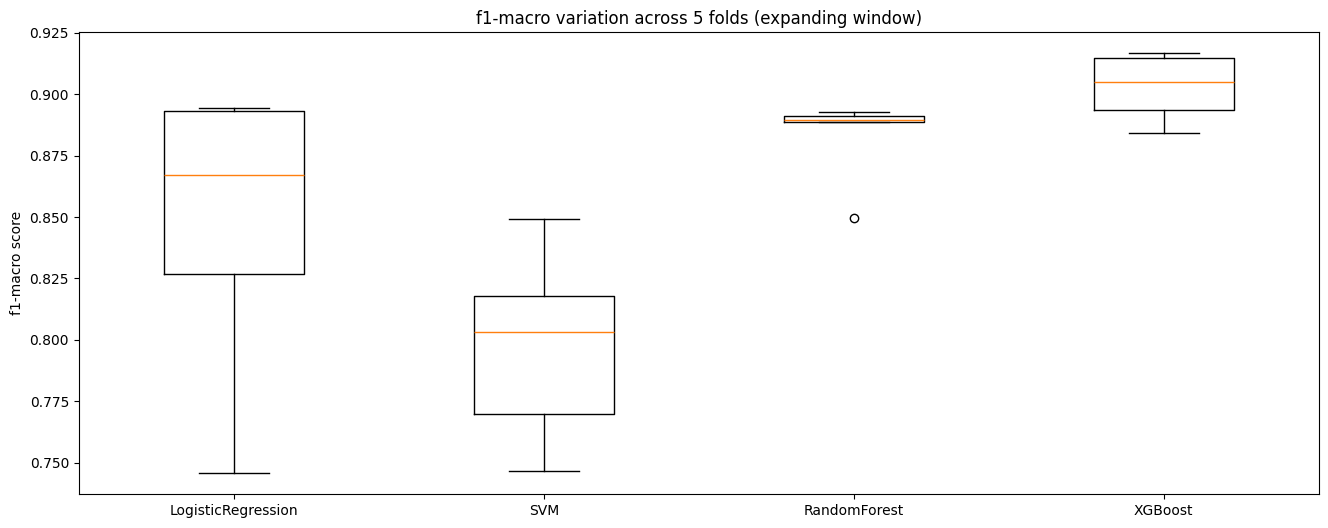

In [103]:
plt.figure(figsize=(16, 6))
fold_data = [res['all_folds'] for res in cv_results]
plt.boxplot(fold_data, tick_labels=[res['model_name'] for res in cv_results])
plt.title("f1-macro variation across 5 folds (expanding window)")
plt.ylabel("f1-macro score")
plt.show()

In [104]:
eval_results = []

for name, model in trained_models_cv.items():
    result_df = eval_model(model, X_test, y_test, label_encoder, model_name=name)
    eval_results.append(result_df)

comparison_df = pd.concat(eval_results, ignore_index=True)
comparison_df = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)
comparison_df.round(4)

,model_name,accuracy,precision,recall,f1,f1_weighted
0,XGBoost,0.9783,0.9677,0.9706,0.9690,0.9784
1,RandomForest,0.9710,0.9686,0.9172,0.9387,0.9705
2,LogisticRegression,0.9385,0.8684,0.9585,0.9072,0.9403
3,SVM,0.8966,0.8584,0.6790,0.6875,0.8778


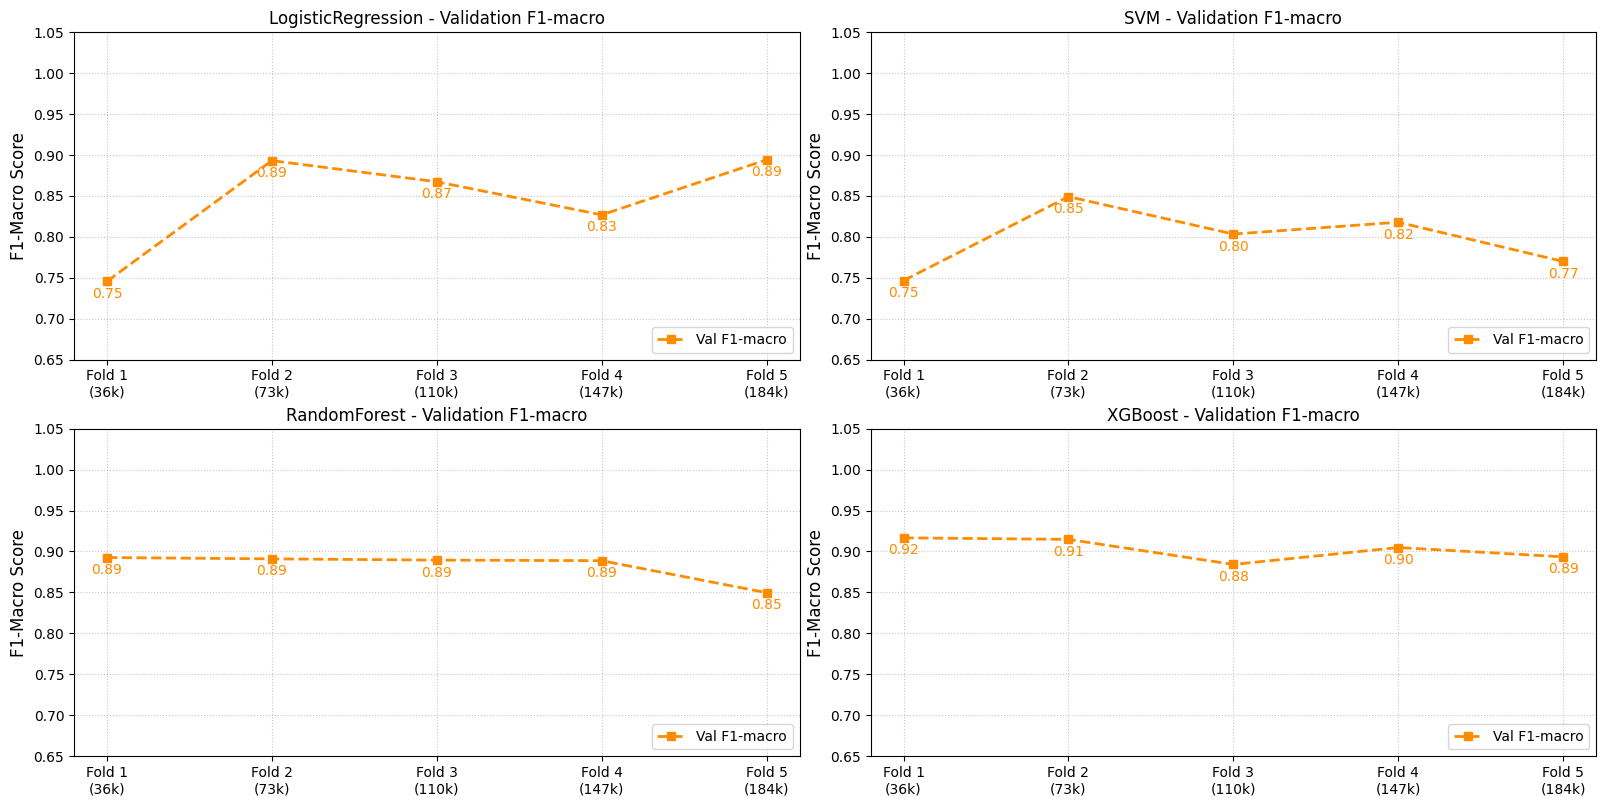

In [110]:
folds = ['Fold 1\n(36k)', 'Fold 2\n(73k)', 'Fold 3\n(110k)', 'Fold 4\n(147k)', 'Fold 5\n(184k)']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 8))
axes = axes.flatten()

for idx, model_data in enumerate(cv_results):
    ax = axes[idx]
    name = model_data['model_name']
    val_scores = model_data['all_folds']
    ax.plot(folds, val_scores, marker='s', linestyle='--', color='darkorange', linewidth=2, label='Val F1-macro')
    ax.set_title(f'{name} - Validation F1-macro')
    ax.set_ylabel('F1-Macro Score', fontsize=12)
    ax.set_ylim(0.65, 1.05)
    for i, txt in enumerate(val_scores):
        ax.annotate(f'{txt:.2f}', (folds[i], val_scores[i] - 0.02), ha='center', color='darkorange')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout(pad=0.5)
plt.show()

In [111]:
for name, model in trained_models_cv.items():
    print(f"Model: {name}")
    print(
        classification_report(
            y_test,
            model.predict(X_test),
            target_names=label_encoder.classes_,
            zero_division=0,
        )
    )
    print("-" * 80)

Model: LogisticRegression
                                precision    recall  f1-score   support

                          good       0.90      0.99      0.95      2172
                      moderate       1.00      0.94      0.97     16424
                     unhealthy       0.73      1.00      0.84      1088
unhealthy for sensitive groups       0.85      0.91      0.88      4986

                      accuracy                           0.94     24670
                     macro avg       0.87      0.96      0.91     24670
                  weighted avg       0.95      0.94      0.94     24670

--------------------------------------------------------------------------------
Model: SVM
                                precision    recall  f1-score   support

                          good       0.98      0.93      0.96      2172
                      moderate       0.92      0.99      0.96     16424
                     unhealthy       0.76      0.04      0.08      1088
unhealthy for 

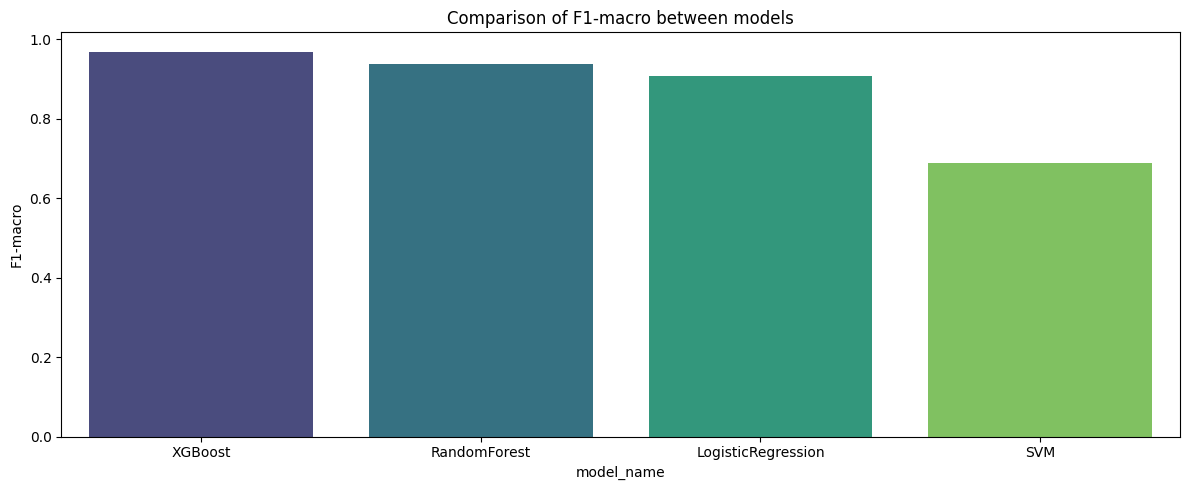

In [112]:
plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_df, x="model_name", y="f1", palette="viridis")
plt.title("Comparison of F1-macro between models")
plt.ylabel("F1-macro")
plt.tight_layout()
plt.show()

In [113]:
best_model_name = comparison_df.iloc[0]["model_name"]
best_model = trained_models_cv[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model by F1-macro: {best_model_name}")

Best model by F1-macro: XGBoost


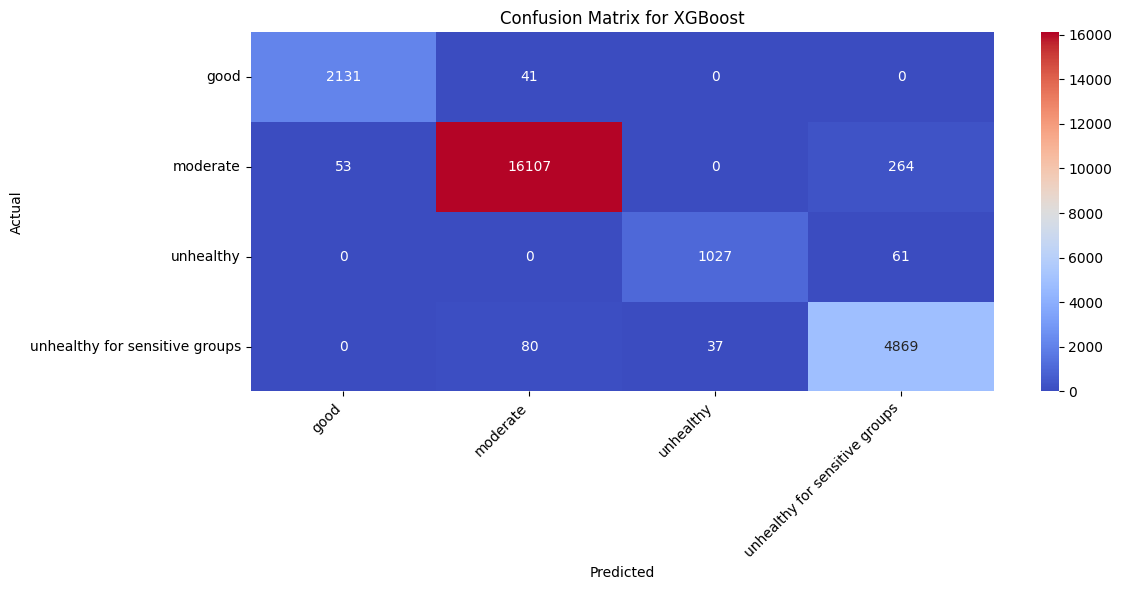

In [114]:
plot_confusion_matrix(
    best_model, X_test, y_test, label_encoder, model_name=best_model_name
)

## Predict


In [115]:
n_samples = 24670
sample_result = predict_model(
    model=best_model,
    df=test_df,
    feature_cols=FEATURE_COLS,
    label_encoder=label_encoder,
    column_transformer=column_transformer,
    n_samples=n_samples,
)

sample_result

,location_id,location_name,date,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,...,day_of_week,is_weekend,season,hour_sin,hour_cos,us_aqi_lag1,us_aqi_lag3,us_aqi,aqi_category,predicted
11286,1583518,Dĩ An,2026-05-04 05:00:00,25.50,95.630830,0.5,1006.06530,98.0,7.415038,5.572114,...,0,0,1,0.965926,2.588190e-01,63.599290,63.705677,63.377655,moderate,moderate
3315,1582436,Dong Xoai,2026-04-01 00:00:00,25.45,74.564870,0.0,999.70180,95.0,12.033103,158.039380,...,2,0,0,0.000000,1.000000e+00,61.453903,92.644550,61.586880,moderate,moderate
13670,9075789,Long Khánh,2026-05-14 04:00:00,25.65,91.438770,0.1,987.81910,89.0,6.037383,206.564990,...,3,0,1,0.866025,5.000000e-01,52.207450,52.260635,52.287240,moderate,moderate
3860,1565022,Thu Dau Mot,2026-04-03 07:00:00,25.65,79.072044,0.0,1010.31330,0.0,8.626865,113.355590,...,4,0,0,0.965926,-2.588190e-01,62.624115,64.281910,61.764190,moderate,moderate
16839,1566559,Tay Ninh,2026-05-27 08:00:00,29.65,76.829840,0.0,1008.84960,99.0,6.369050,227.290630,...,2,0,1,0.866025,-5.000000e-01,100.614586,96.241140,102.416680,unhealthy for sensitive groups,unhealthy for sensitive groups
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,1582436,Dong Xoai,2026-06-16 02:00:00,25.25,94.767830,0.4,999.89233,93.0,1.310420,254.054530,...,1,0,1,0.500000,8.660254e-01,83.679080,83.945040,83.554960,moderate,moderate
5390,1587923,Bien Hoa,2026-04-09 16:00:00,32.55,48.228510,0.0,1008.22380,5.0,14.897651,168.147020,...,3,0,0,-0.866025,-5.000000e-01,71.445030,73.475174,80.314610,moderate,moderate
860,1562414,Vũng Tàu,2026-03-21 19:00:00,26.10,84.592790,0.0,1009.20135,11.0,21.851286,101.402466,...,5,1,0,-0.965926,2.588190e-01,60.119045,52.792550,61.607147,moderate,moderate
15795,12382296,Thuận An,2026-05-23 00:00:00,27.70,87.582460,0.0,1008.90680,96.0,4.557236,189.090200,...,5,1,1,0.000000,1.000000e+00,93.182625,94.512410,93.076240,moderate,moderate


In [116]:
correct = (sample_result["aqi_category"] == sample_result["predicted"]).sum()
print(f"Predictions correct: {correct}/{n_samples}")

Predictions correct: 24134/24670


# Save model


In [117]:
MODEL_DIR = "../models"

In [ ]:
joblib.dump(best_model, os.path.join(MODEL_DIR, f"{best_model_name}_best_model.joblib"))
joblib.dump(label_encoder, os.path.join(MODEL_DIR, "label_encoder.joblib"))
joblib.dump(FEATURE_COLS, os.path.join(MODEL_DIR, "feature_cols.joblib"))
joblib.dump(column_transformer, os.path.join(MODEL_DIR, "column_transformer.joblib"))

comparison_df.to_csv(os.path.join(MODEL_DIR, "model_comparison.csv"), index=False)
print(
    f"Best model saved to {os.path.join(MODEL_DIR, f'{best_model_name}_best_model.joblib')}"
)